# Analytics Overview
Same analytics as the Superset **Analytics Overview** dashboard, computed from the PostgreSQL `contacts` database
(`users` + `analytics_events`). Connection details come from the `POSTGRES_*` environment variables Aspire sets on this container.

In [1]:
import os
from urllib.parse import quote_plus

import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import create_engine

pg = "postgresql+psycopg://{u}:{p}@{h}:{port}/{db}".format(
    u=os.environ["POSTGRES_USER"], p=quote_plus(os.environ["POSTGRES_PASSWORD"]),
    h=os.environ["POSTGRES_HOST"], port=os.environ["POSTGRES_PORT"], db=os.environ["POSTGRES_DATABASE"],
)
engine = create_engine(pg)
plt.rcParams.update({"figure.figsize": (7, 4), "axes.spines.top": False, "axes.spines.right": False})

## Load events (joined with users)

In [2]:
events = pd.read_sql(
    """SELECT e.id, e.event_type, e.page, e.occurred_at, u.username, u.role
       FROM analytics_events e JOIN users u ON u.id = e.user_id""",
    engine, parse_dates=["occurred_at"],
)
events.head()

,id,event_type,page,occurred_at,username,role
0,1,purchase,/reports,2026-10-03 10:02:07.248846+00:00,liam2,viewer
1,2,page_view,/contacts,2026-09-24 20:02:07.248846+00:00,olivia1,editor
2,3,purchase,/home,2026-09-10 20:02:07.248846+00:00,isabella9,admin
3,4,purchase,/reports,2026-09-25 09:02:07.248846+00:00,noah4,editor
4,5,purchase,/users,2026-10-04 12:02:07.248846+00:00,james8,viewer


## Total events

In [3]:
print(f"Total events: {len(events):,}   |   users: {events.username.nunique()}   |   "
      f"{events.occurred_at.min():%Y-%m-%d} to {events.occurred_at.max():%Y-%m-%d}")

Total events: 200   |   users: 10   |   2026-09-04 to 2026-10-04


## Events by type

,events
event_type,
purchase,45
click,41
search,39
signup,38
page_view,37


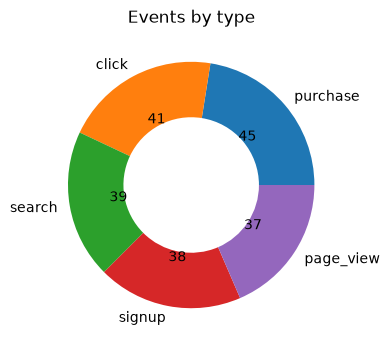

In [4]:
by_type = events.event_type.value_counts()
ax = by_type.plot.pie(autopct=lambda p: f"{p * by_type.sum() / 100:.0f}", wedgeprops={"width": 0.45}, ylabel="")
ax.set_title("Events by type")
by_type.to_frame("events")

## Events by page

,events
page,
/contacts,40
/home,41
/reports,45
/settings,37
/users,37


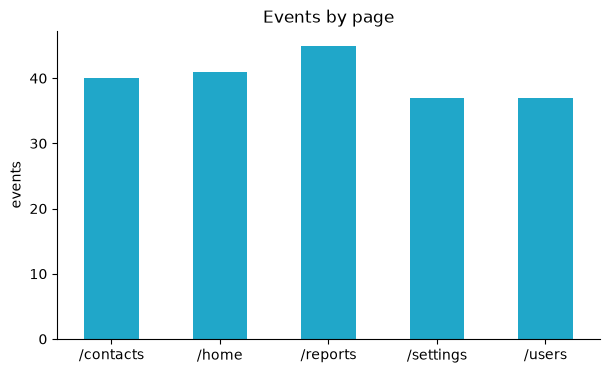

In [5]:
by_page = events.page.value_counts().sort_index()
ax = by_page.plot.bar(rot=0, color="#20a7c9")
ax.set_title("Events by page"); ax.set_xlabel(""); ax.set_ylabel("events")
by_page.to_frame("events")

## Top 5 users by activity

,events
username,
liam2,27
noah4,24
ava5,23
isabella9,21
sophia7,20


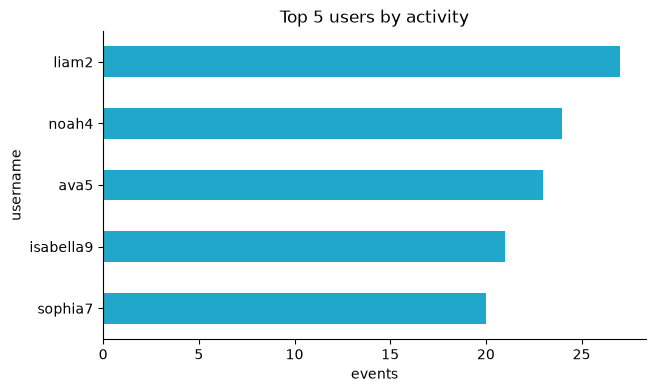

In [6]:
top_users = events.username.value_counts().head(5).sort_values()
ax = top_users.plot.barh(color="#20a7c9")
ax.set_title("Top 5 users by activity"); ax.set_xlabel("events")
top_users.sort_values(ascending=False).to_frame("events")

## Events per day

,events per day
count,31.0
mean,6.5
std,2.3
min,2.0
25%,5.0
50%,6.0
75%,8.0
max,11.0


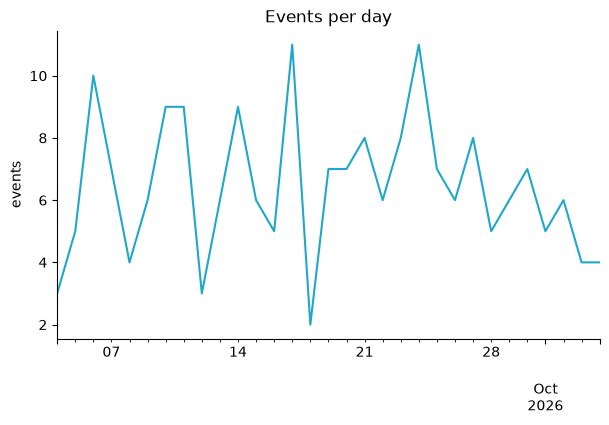

In [7]:
per_day = events.set_index("occurred_at").resample("D").size()
ax = per_day.plot.line(color="#20a7c9")
ax.set_title("Events per day"); ax.set_xlabel(""); ax.set_ylabel("events")
per_day.describe().round(1).to_frame("events per day")

## Bonus: event type by page

In [8]:
pd.crosstab(events.page, events.event_type, margins=True)

event_type,click,page_view,purchase,search,signup,All
page,,,,,,
/contacts,5,9,12,9,5,40
/home,9,9,11,5,7,41
/reports,13,5,8,11,8,45
/settings,5,7,8,10,7,37
/users,9,7,6,4,11,37
All,41,37,45,39,38,200
